In [96]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv("../../data/credit_card_transactions.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [97]:
print(df.head())

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      long city_pop  \
0    Banks      F                561 Perry Cove  ...  -81.1781     3495   
1     Gill      F  43039 Riley Greens Suite 393  ... -11

In [98]:
print("\n=== Missing Values Count ===")
print(df.isnull().sum().sort_values(ascending=False))


=== Missing Values Count ===
merch_zipcode            195973
trans_date_trans_time         0
is_fraud                      0
merch_long                    0
merch_lat                     0
unix_time                     0
trans_num                     0
dob                           0
job                           0
city_pop                      0
long                          0
lat                           0
Unnamed: 0                    0
state                         0
city                          0
street                        0
gender                        0
last                          0
first                         0
amt                           0
category                      0
merchant                      0
cc_num                        0
zip                           0
dtype: int64


In [99]:
df = df.drop(columns=["Unnamed: 0"])
df = df.drop(columns=[
    "merch_zipcode",
    "first",
    "last",
    "street",
    "cc_num",
    "trans_num",
    "merchant",
    "job",
    "city"
])

In [100]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
df["month"] = df["trans_date_trans_time"].dt.month
df.shape

(1296675, 17)

In [101]:
df["dob"] = pd.to_datetime(df["dob"], errors="coerce")
df["age"] = ((pd.to_datetime("today") - df["dob"]).dt.days // 365).fillna(0).astype(int)

In [102]:
categorical_cols = ["gender", "state", "category"]
df['categories'] = df['category']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.shape

(1296675, 80)

In [103]:
from sklearn.preprocessing import StandardScaler
df["hour_raw"] = pd.to_datetime(df["trans_date_trans_time"]).dt.hour
numeric_cols = ["amt", "lat", "long", "merch_lat", "merch_long", "city_pop", "age", "hour", "day_of_week", "month"]
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [104]:
print(df.head())
print(df.shape)

  trans_date_trans_time       amt    zip       lat      long  city_pop  \
0   2019-01-01 00:00:18 -0.407826  28654 -0.484420  0.657620 -0.282589   
1   2019-01-01 00:00:44  0.230039  99160  2.039120 -2.033870 -0.293670   
2   2019-01-01 00:00:51  0.934149  83252  0.717754 -1.601537 -0.280406   
3   2019-01-01 00:01:16 -0.158132  59632  1.515617 -1.590766 -0.287742   
4   2019-01-01 00:03:06 -0.177094  24433 -0.023035  0.782279 -0.293835   

         dob   unix_time  merch_lat  merch_long  ...  category_health_fitness  \
0 1988-03-09  1325376018  -0.494354    0.593864  ...                    False   
1 1978-06-21  1325376044   2.078699   -2.030341  ...                    False   
2 1962-01-19  1325376051   0.902849   -1.592323  ...                    False   
3 1967-01-12  1325376076   1.662886   -1.621848  ...                    False   
4 1986-03-28  1325376186   0.026941    0.841909  ...                    False   

   category_home  category_kids_pets  category_misc_net  category_mi

In [119]:
from sklearn.model_selection import train_test_split 
X = df.drop(columns=["is_fraud"])
datetime_cols = X.select_dtypes(include=["datetime64[ns]"]).columns
X = X.drop(columns=datetime_cols)  
X = X.select_dtypes(include=["number", "bool"])
X = X.astype(float)
y = df["is_fraud"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [120]:
print(df["is_fraud"].value_counts())
df["is_fraud"].value_counts(normalize=True)

is_fraud
0    1289169
1       7506
Name: count, dtype: int64


is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

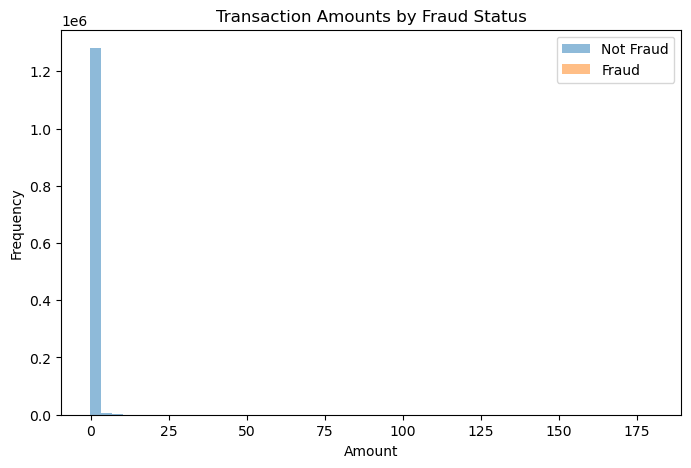

In [114]:
plt.figure(figsize=(8,5))

plt.hist(df[df["is_fraud"] == 0]["amt"],
         bins=50,
         alpha=0.5,
         label="Not Fraud")

plt.hist(df[df["is_fraud"] == 1]["amt"],
         bins=50,
         alpha=0.5,
         label="Fraud")

plt.legend()
plt.title("Transaction Amounts by Fraud Status")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

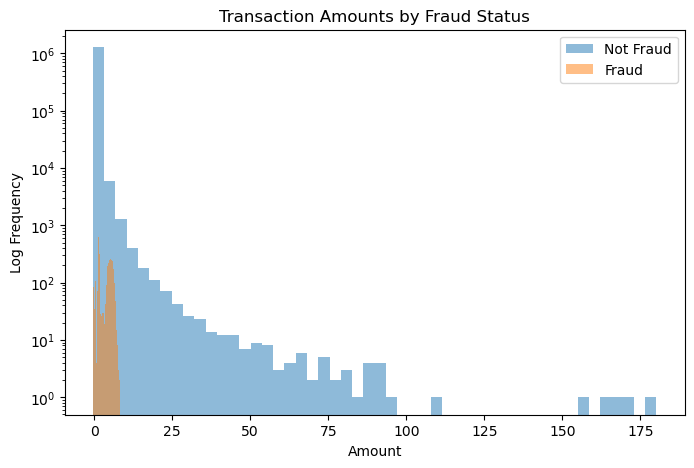

In [121]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df["is_fraud"] == 0]["amt"],
    bins=50,
    alpha=0.5,
    label="Not Fraud",
    log=True
)

plt.hist(
    df[df["is_fraud"] == 1]["amt"],
    bins=50,
    alpha=0.5,
    label="Fraud",
    log=True
)

plt.title("Transaction Amounts by Fraud Status")
plt.xlabel("Amount")
plt.ylabel("Log Frequency")
plt.legend()
plt.show()

**Fraudtransactions appear to occur within a narrower transaction amount range, while legitimate transactions span a much wider distribution of transaction amounts, including many extremely large purchases.**

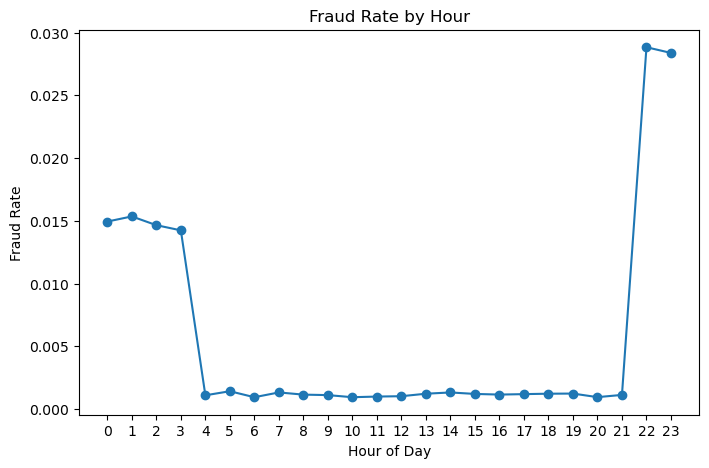

In [122]:
fraud_by_hour = df.groupby("hour_raw")["is_fraud"].mean()

plt.figure(figsize=(8,5))

plt.plot(
    fraud_by_hour.index,
    fraud_by_hour.values,
    marker="o"
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")

plt.xticks(range(24))

plt.show()

**Fraud rates are significantly higher during late night and early morning hours, especially around 10 PM–3 AM, where the fraud rate rises to nearly 3%. During most daytime hours, fraud rates remain relatively low and stable, suggesting that unusual transaction timing may be an important indicator of fraudulent activity.**

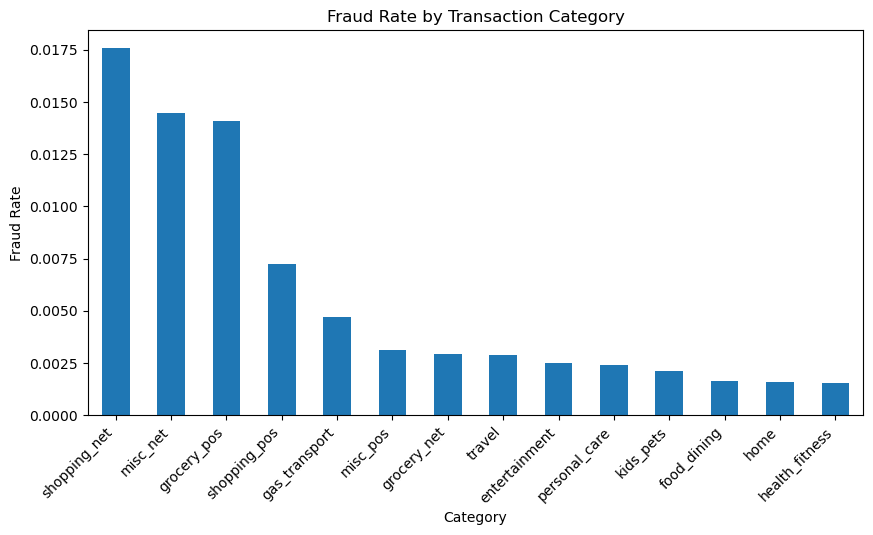

In [123]:
category_fraud = df.groupby("categories")["is_fraud"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
category_fraud.plot(kind="bar")
plt.title("Fraud Rate by Transaction Category")
plt.xlabel("Category")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

**Fraud rates were highest for online shopping, miscellaneous online purchases, and grocery point-of-sale transactions, while categories such as dining, home, and health/fitness showed relatively low fraud rates. This info shouldn't be too useful in determining fraud.****

In [124]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(1037340, 77)
(259335, 77)
is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64
is_fraud
0    0.994212
1    0.005788
Name: proportion, dtype: float64


In [125]:
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [127]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
log_preds = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, log_preds))

log_auc = roc_auc_score(y_test, log_probs)
log_pr_auc = average_precision_score(y_test, log_probs)

print("Logistic Regression ROC-AUC:", log_auc)
print("Logistic Regression PR-AUC:", log_pr_auc)

              precision    recall  f1-score   support

           0       0.99      0.50      0.67    257834
           1       0.01      0.51      0.01      1501

    accuracy                           0.50    259335
   macro avg       0.50      0.51      0.34    259335
weighted avg       0.99      0.50      0.67    259335

Logistic Regression ROC-AUC: 0.5024014335548733
Logistic Regression PR-AUC: 0.005987981763927841


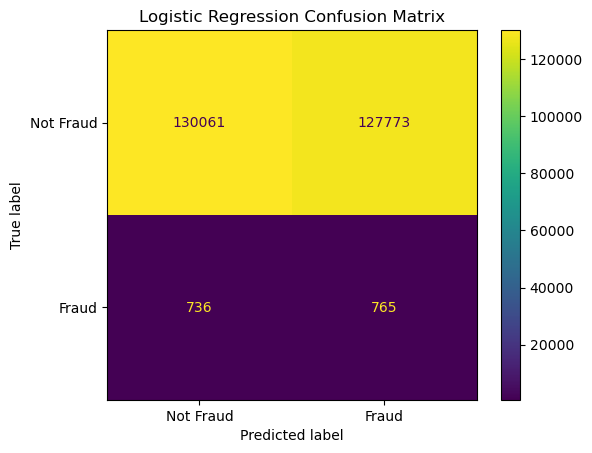

In [128]:
cm = confusion_matrix(y_test, log_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Fraud", "Fraud"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [129]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [130]:
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

In [131]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    257834
           1       0.26      0.91      0.41      1501

    accuracy                           0.98    259335
   macro avg       0.63      0.95      0.70    259335
weighted avg       1.00      0.98      0.99    259335



In [132]:
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))

ROC-AUC: 0.9888849436444647


In [133]:
 from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Fraud", "Fraud"]
)

plt.figure(figsize=(6,6))

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

IndentationError: unexpected indent (633105907.py, line 1)

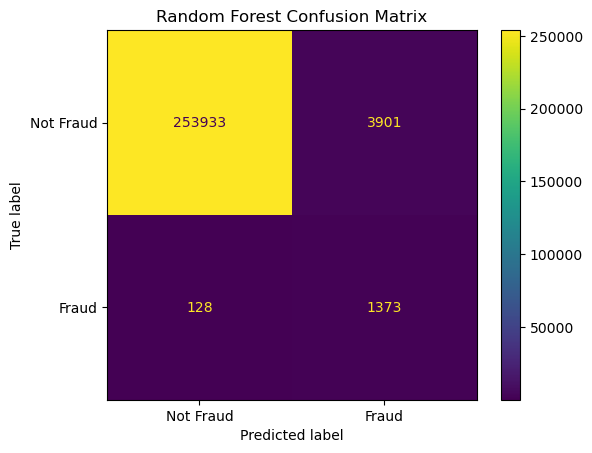

In [134]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Fraud", "Fraud"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

**Logistic Regression performed horribly because it tries to separate fraud and non-fraud using mostly linear relationships, but fraud behavior is usually much more complicated than that. Things like transaction time, amount, location, and spending category probably interact with each other in nonlinear ways, so the model struggled and ended up labeling a huge number of normal transactions as fraud. The Random Forest worked much better because tree-based models are able to pick up on more complex patterns and interactions automatically, which is why the performance improved so dramatically compared to Logistic Regression. Looking at the confusion matrix, the model catches most fraud cases while only missing a relatively small amount, which suggests it actually learned meaningful signals from the data instead of just guessing randomly. That said, the results are almost too good, especially with an ROC-AUC close to 0.99, so there’s still a chance the model could be overfitting or accidentally benefiting from some hidden leakage in the features, meaning we’d want to investigate further before fully trusting it in a real-world fraud detection system.**

In [139]:
# Baseline model: predict "Not Fraud" for every transaction
baseline_preds = np.zeros(len(y_test), dtype=int)
baseline_probs = np.zeros(len(y_test))

print("BASELINE MODEL: Always Predict Not Fraud")
print(classification_report(y_test, baseline_preds, zero_division=0))

baseline_cm = confusion_matrix(y_test, baseline_preds)
baseline_roc_auc = roc_auc_score(y_test, baseline_probs)
baseline_pr_auc = average_precision_score(y_test, baseline_probs)

print("Baseline Confusion Matrix:")
print(baseline_cm)
print("Baseline ROC-AUC:", baseline_roc_auc)
print("Baseline PR-AUC:", baseline_pr_auc)


# Decision Tree model
tree_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_preds = tree_model.predict(X_test)
tree_probs = tree_model.predict_proba(X_test)[:, 1]

print("\nDECISION TREE MODEL")
print(classification_report(y_test, tree_preds, zero_division=0))

tree_cm = confusion_matrix(y_test, tree_preds)
tree_roc_auc = roc_auc_score(y_test, tree_probs)
tree_pr_auc = average_precision_score(y_test, tree_probs)

print("Decision Tree Confusion Matrix:")
print(tree_cm)
print("Decision Tree ROC-AUC:", tree_roc_auc)
print("Decision Tree PR-AUC:", tree_pr_auc)

#comparison table
comparison = pd.DataFrame({
    "Model": ["Always Not Fraud Baseline", "Decision Tree"],
    "Accuracy": [
        (baseline_preds == y_test).mean(),
        (tree_preds == y_test).mean()
    ],
    "ROC-AUC": [
        baseline_roc_auc,
        tree_roc_auc
    ],
    "PR-AUC": [
        baseline_pr_auc,
        tree_pr_auc
    ],
    "Fraud Recall": [
        classification_report(y_test, baseline_preds, output_dict=True, zero_division=0)["1"]["recall"],
        classification_report(y_test, tree_preds, output_dict=True, zero_division=0)["1"]["recall"]
    ],
    "Fraud Precision": [
        classification_report(y_test, baseline_preds, output_dict=True, zero_division=0)["1"]["precision"],
        classification_report(y_test, tree_preds, output_dict=True, zero_division=0)["1"]["precision"]
    ],
    "Fraud F1": [
        classification_report(y_test, baseline_preds, output_dict=True, zero_division=0)["1"]["f1-score"],
        classification_report(y_test, tree_preds, output_dict=True, zero_division=0)["1"]["f1-score"]
    ]
})

comparison

BASELINE MODEL: Always Predict Not Fraud
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    257834
           1       0.00      0.00      0.00      1501

    accuracy                           0.99    259335
   macro avg       0.50      0.50      0.50    259335
weighted avg       0.99      0.99      0.99    259335

Baseline Confusion Matrix:
[[257834      0]
 [  1501      0]]
Baseline ROC-AUC: 0.5
Baseline PR-AUC: 0.005787880540613492

DECISION TREE MODEL
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    257834
           1       0.13      0.98      0.23      1501

    accuracy                           0.96    259335
   macro avg       0.56      0.97      0.60    259335
weighted avg       0.99      0.96      0.98    259335

Decision Tree Confusion Matrix:
[[247854   9980]
 [    31   1470]]
Decision Tree ROC-AUC: 0.9819545114052874
Decision Tree PR-AUC: 0.495106730319239


,Model,Accuracy,ROC-AUC,PR-AUC,Fraud Recall,Fraud Precision,Fraud F1
0,Always Not Fraud Baseline,0.994212,0.500000,0.005788,0.000000,0.000000,0.000000
1,Decision Tree,0.961397,0.981955,0.495107,0.979347,0.128384,0.227009
